In [2]:
# Install required packages
!pip install ultralytics opencv-python scikit-image scipy pandas matplotlib seaborn -q

print("✓ All dependencies installed")

✓ All dependencies installed


In [ ]:
from pathlib import Path
import sys

# Ensure backend root is available for imports when running from notebooks/.
backend_root = Path.cwd()
if backend_root.name == "notebooks":
    backend_root = backend_root.parent
if str(backend_root) not in sys.path:
    sys.path.append(str(backend_root))

from app.services.feature_extraction import SecchiDiskFeatureExtractor

print("✓ Feature Extractor module imported")

✓ Feature Extractor (Improved) loaded


In [ ]:
from app.services.score_calculator import VisibilityScoreCalculator

print("✓ Visibility Score Calculator module imported")

✓ Visibility Score Calculator (Improved) loaded


In [ ]:
from app.services.source_detector import TurbiditySourceDetector
from app.services.classifier import TurbidityClassifier

print("✓ Source Detector and Turbidity Classifier modules imported")

✓ Source-Aware Turbidity Classifier loaded


In [ ]:
from app.services.system import SecchiTurbiditySystem

import cv2
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

print("✓ Source-aware Turbidity Assessment System module imported")

✓ SOURCE-AWARE Turbidity Assessment System loaded


In [7]:
# Initialize system

# Path to your trained YOLOv8 model
yolo_model_path = '/kaggle/input/datasets/naikouu/secchi-disk-turbidity-model/secchi_disk_turbidity_model.pt'

# Classification standard
# - 'epa': EPA Water Quality Standards (general freshwater)
# - 'carlson': Carlson Trophic State Index (lakes/reservoirs)
# - 'marine': Oceanographic standards (coastal/marine)
# - 'freshwater': Freshwater rivers/streams
standard = 'auto'
 
# Choose weighting method:
# - 'physics': Edge clarity dominant (turbidity physics)
# - 'balanced': Balanced across feature groups
# - 'edge_focused': Maximum weight on edge features
weighting_method = 'balanced'
 
# Initialize
system = SecchiTurbiditySystem(
    yolo_model_path=yolo_model_path,
    standard=standard,
    weighting_method=weighting_method
)
 

✓ YOLOv8 model loaded from: /kaggle/input/datasets/naikouu/secchi-disk-turbidity-model/secchi_disk_turbidity_model.pt
✓ Turbidity Classifier initialized
  Mode: AUTO (source-aware)
✓ SOURCE-AWARE Turbidity System initialized
  Mode: AUTO - will detect turbidity source and use appropriate standard
    Algal → Carlson TSI standard
    Sediment → Sediment-based standard
    Mixed → EPA balanced standard
  Weighting: BALANCED



SOURCE-AWARE TURBIDITY ASSESSMENT

TURBIDITY SOURCE DETECTED:
  Primary Source: MIXED
  Detection Confidence: 0.71
  Algal Score: 0.35
  Sediment Score: 0.65

Standard Selected: EPA

CLASSIFICATION:
  Category: High Turbidity
  Visibility Score: 0.187
  Confidence: Low (0.06)

DETECTION:
  YOLO Confidence: 0.875

KEY FEATURES:
  Edge Clarity (Single): 0.0045
  Edge Clarity (Multi-scale): 0.0040
  Gradient Consistency: 0.3070
  Sharpness: 4.67
  Contrast: 50.94

TOP CONTRIBUTING FEATURES:
  1. contrast_std: 0.0425
  2. gradient_peak_ratio: 0.0346
  3. contrast_range: 0.0256

ESTIMATED WATER QUALITY METRICS:
  Turbidity (NTU): 6.6 NTU [2.8-10.4]
  Secchi Depth: 0.4 m [0.24-0.55]
  Carlson TSI: N/A (TSI not applicable - turbidity is sediment-based, not algal)
  Estimate Confidence: 0.06

CATEGORY INFORMATION:
  Description: Water is very murky, disk barely or not visible
  Visibility: Poor
  Typical Causes: Mixed sources: algae, sediment, organic matter
  NTU Range: > 120 NTU
  Secchi De

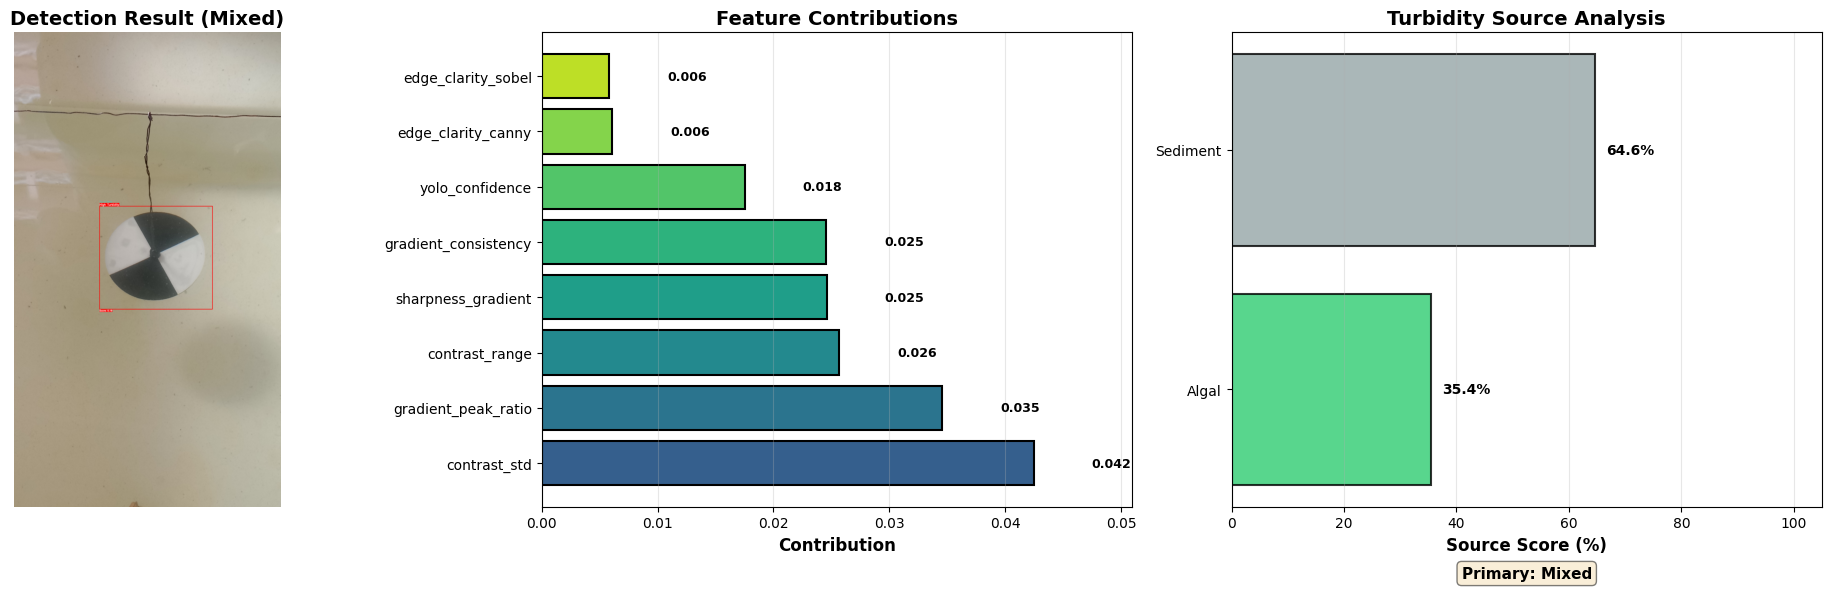

In [8]:
# Test on single image

# Test image path (change to your image)
test_image = '/kaggle/working/secchi_disk_data/test/images/102_jpg.rf.iLToqm5mD9Btic7Hpzmh.jpg'

# Assess turbidity
result = system.assess_single_image(
    image_path=test_image,
    visualize=True,
    verbose=True
)

In [10]:
# Process validation

import glob

# Get all validation images
val_images_dir = '/kaggle/working/secchi_disk_data/valid/images'
val_images = glob.glob(f'{val_images_dir}/*.jpg') + glob.glob(f'{val_images_dir}/*.png')

print(f"Found {len(val_images)} validation images")

# Process all images
results_df = system.assess_batch(
    image_paths=val_images,
    save_results=True,
    output_path='/kaggle/working/turbidity_assessment_results.csv', 
    adaptive_scoring=False,
    show_progress=True
)

Found 87 validation images

Processing 87 images (SOURCE-AWARE MODE)...
----------------------------------------------------------------------

[1/87] WIN_20260204_08_27_19_Pro_mp4-0026_jpg.rf.IAqLVuZJFVM4ruZpRydt.jpg
  → High Turbidity (score: 0.122, source: algal, std: carlson)

[2/87] WIN_20260128_15_35_19_Pro_mp4-0024_jpg.rf.ZYEQlOC71wUD90C4LTOa.jpg
  → Moderately Turbid (score: 0.322, source: mixed, std: epa)

[3/87] WIN_20260128_15_35_19_Pro_mp4-0025_jpg.rf.Of1t9GR0YNWtfVAMoer6.jpg
  → Moderately Turbid (score: 0.312, source: mixed, std: epa)

[4/87] 80_jpg.rf.OeWbsYhbdI63vHt11I4K.jpg
  → High Turbidity (score: 0.175, source: sediment, std: sediment)

[5/87] WIN_20260204_08_27_19_Pro_mp4-0102_jpg.rf.f6S8kqSXxNg368dKieQQ.jpg
  → High Turbidity (score: 0.115, source: algal, std: carlson)

[6/87] 15_jpg.rf.2gJcraBa6c5T5SsgDAdZ.jpg
  → High Turbidity (score: 0.192, source: sediment, std: sediment)

[7/87] 28_jpg.rf.gv4vpglNZ5F4emHFTZVZ.jpg
  → High Turbidity (score: 0.171, source: se

✓ Summary visualization saved


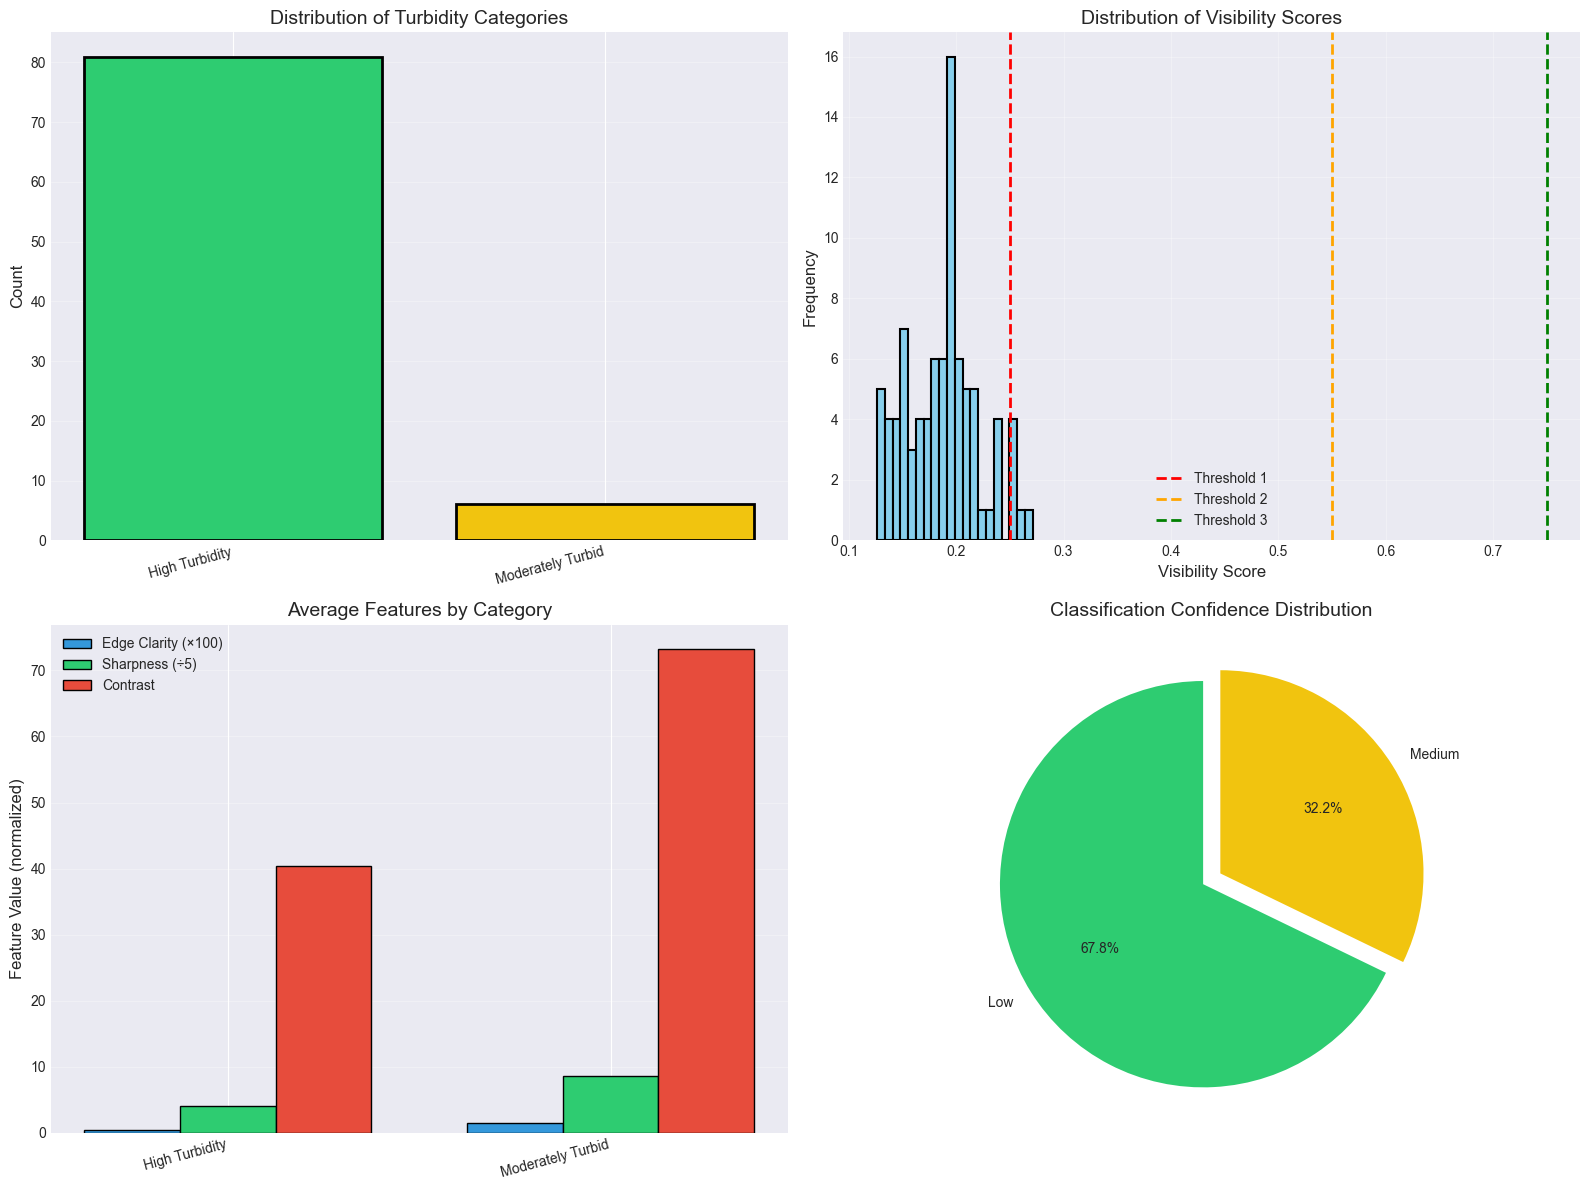

In [24]:
# Visualize results

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Category distribution
category_counts = results_df['turbidity_category'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
axes[0, 0].bar(range(len(category_counts)), category_counts.values, 
               color=colors[:len(category_counts)], edgecolor='black', linewidth=2)
axes[0, 0].set_xticks(range(len(category_counts)))
axes[0, 0].set_xticklabels(category_counts.index, rotation=15, ha='right')
axes[0, 0].set_ylabel('Count', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Distribution of Turbidity Categories', fontweight='bold', fontsize=14)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Visibility score distribution
axes[0, 1].hist(results_df[results_df['disk_detected']]['visibility_score'], 
                bins=20, color='skyblue', edgecolor='black', linewidth=1.5)
axes[0, 1].axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='Threshold 1')
axes[0, 1].axvline(x=0.55, color='orange', linestyle='--', linewidth=2, label='Threshold 2')
axes[0, 1].axvline(x=0.75, color='green', linestyle='--', linewidth=2, label='Threshold 3')
axes[0, 1].set_xlabel('Visibility Score', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Distribution of Visibility Scores', fontweight='bold', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature comparison by category
detected_df = results_df[results_df['disk_detected']].copy()
categories = detected_df['turbidity_category'].unique()

feature_means = detected_df.groupby('turbidity_category')[['edge_clarity', 'sharpness', 'contrast']].mean()

x = np.arange(len(feature_means.index))
width = 0.25

axes[1, 0].bar(x - width, feature_means['edge_clarity'] * 100, width, 
               label='Edge Clarity (×100)', color='#3498db', edgecolor='black')
axes[1, 0].bar(x, feature_means['sharpness'] / 5, width, 
               label='Sharpness (÷5)', color='#2ecc71', edgecolor='black')
axes[1, 0].bar(x + width, feature_means['contrast'], width, 
               label='Contrast', color='#e74c3c', edgecolor='black')

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(feature_means.index, rotation=15, ha='right')
axes[1, 0].set_ylabel('Feature Value (normalized)', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Average Features by Category', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Confidence distribution
conf_counts = results_df['confidence'].value_counts()
axes[1, 1].pie(conf_counts.values, labels=conf_counts.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#f1c40f', '#e74c3c'], startangle=90,
               explode=[0.05] * len(conf_counts))
axes[1, 1].set_title('Classification Confidence Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('/kaggle/working/turbidity_assessment_summary.png', dpi=300, bbox_inches='tight')
print("✓ Summary visualization saved")
plt.show()

In [25]:
# Threshold analysis

# Get detected images only
detected_df = results_df[results_df['disk_detected']].copy()

if len(detected_df) > 0:
    print("="*70)
    print("THRESHOLD ANALYSIS")
    print("="*70)
    
    # Calculate percentiles
    scores = detected_df['visibility_score'].values
    
    print(f"\nVisibility Score Statistics:")
    print(f"  Min:  {scores.min():.3f}")
    print(f"  25th: {np.percentile(scores, 25):.3f}")
    print(f"  50th: {np.percentile(scores, 50):.3f}")
    print(f"  75th: {np.percentile(scores, 75):.3f}")
    print(f"  Max:  {scores.max():.3f}")
    
    print(f"\nCurrent Thresholds: {system.classifier.thresholds}")
    
    print(f"\nSuggested Thresholds (based on percentiles):")
    print(f"  Option 1 (Percentile-based): {[np.percentile(scores, 25), np.percentile(scores, 50), np.percentile(scores, 75)]}")
    print(f"  Option 2 (Equal spacing): {[0.25, 0.50, 0.75]}")
    
    # Show current category distribution
    print(f"\nCurrent Category Distribution:")
    for cat in system.classifier.categories:
        count = (detected_df['turbidity_category'] == cat).sum()
        pct = count / len(detected_df) * 100
        print(f"  {cat}: {count} ({pct:.1f}%)")
    
    print("\n" + "="*70)
    print("RECOMMENDATION:")
    print("="*70)
    print("If distribution is unbalanced, adjust thresholds to better")
    print("separate categories. Look for gaps in the histogram above.")
    print("="*70)

THRESHOLD ANALYSIS

Visibility Score Statistics:
  Min:  0.126
  25th: 0.157
  50th: 0.191
  75th: 0.206
  Max:  0.271

Current Thresholds: [0.25, 0.55, 0.75]

Suggested Thresholds (based on percentiles):
  Option 1 (Percentile-based): [np.float64(0.15745206038093618), np.float64(0.19147308011433528), np.float64(0.20648315000486514)]
  Option 2 (Equal spacing): [0.25, 0.5, 0.75]

Current Category Distribution:
  High Turbidity: 81 (93.1%)
  Moderately Turbid: 6 (6.9%)
  Slightly Turbid: 0 (0.0%)
  Clear Water: 0 (0.0%)

RECOMMENDATION:
If distribution is unbalanced, adjust thresholds to better
separate categories. Look for gaps in the histogram above.
